RNN - Erro dos pesos computados e usado somente durante a iteração

In [1]:
import numpy as np
from numpy import linalg as LA
import pandas as pd
import operator as op
import ipynbname
import math
import matplotlib.cm as cm
import optuna
from optuna.samplers import RandomSampler
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_pareto_front
from optuna.importance import get_param_importances
from optuna.exceptions import TrialPruned
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib as mpl
#from Testing.RTLO import *
from Functions.RLS import *
from Functions.Graphs import *
from sklearn.metrics import root_mean_squared_error as RMSE
from sklearn.metrics import mean_absolute_percentage_error as MAPE
FileName = ipynbname.name()

params = [17, 18, 3, 1e-08, 1e-08, 1e-05, 1e-08, 10]
df = pd.read_csv(r'Dataset\Bearing1_1.csv')
sig = df['PC1'].values

def prepare_data(sig, n, m):
    X, Y = [], []
    # O shift (s) é calculado para alinhar o final de Y com a predição futura
    # Seguindo sua lógica: se n=4, m=3 -> Y começa no índice 2 (hi_3)
    s = n - m + 1 
    
    for i in range(len(sig) - n - 1):
        X.append(sig[i : i + n])
        Y.append(sig[i + s : i + s + m])
        
    return np.array(X), np.array(Y)

def PlotPredError(rtlo,w=9,h=3):
    s = len(rtlo.yWAPE)
    t = rtlo.t
    fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(w, h))
    axes = axes.flatten()
    ax1,ax2,ax3,ax4 = axes[0], axes[1], axes[2], axes[3]

    ax1.plot(t, rtlo.yR, color='black',label='Y-Real', linestyle='-')
    ax1.plot(t, rtlo.yP, color='blue',label='Y-Pred', linestyle='-')
    ax1.plot(t, rtlo.yL, color='blue', linestyle='--')
    ax1.plot(t, rtlo.yU, color='blue', linestyle='--')
    
    ax1.set_title('Y - Real x Prediction')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y', color='black')
    ax1.legend()

    ax2.plot(t, rtlo.eR, color='black',label='e-Real', linestyle='-')
    ax2.plot(t, rtlo.eP, color='blue',label='e-Pred', linestyle='-')
    ax2.set_title('Error - Real x Prediction')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Prediction Error', color='black') 
    ax2.legend()
    
    ax3.plot(t[-s:], rtlo.yWAPE, color='blue',label='WAPE', linestyle='-')
    ax3.set_title('Prediction WAPE')
    ax3.set_xlabel('X')
    ax3.set_ylabel('WAPE', color='black') 

    ax4.plot(t[-s:], rtlo.rWAPE, color='blue',label='WAPE', linestyle='-')
    ax4.set_title('RUL Prediction WAPE')
    ax4.set_xlabel('X')
    ax4.set_ylabel('WAPE', color='black') 

    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    plt.show()


In [367]:
def TANH(x):
    return np.tanh(x)
    #return 1 / (1 + np.exp(-x))
    #return np.maximum(0, x)

def dTANH(x):
    #return 1/np.cosh(10*np.tanh(x/10))**2  # the tanh prevents oveflow
    return 1-(TANH(x)**2)
    #return TANH(x)*(1-TANH(x))
    #return np.where(x > 0, 1, 0)

def split_matrix(A):
    Ap = np.where(A > 0, A, 0)
    An = np.where(A < 0, A, 0)
    return An, Ap

def get_interval(A):
    v_max = np.max(A, axis=0)
    v_min = np.min(A, axis=0)
    
    return v_min, v_max

class RTLO:
    def __init__(self, nI,nR,nO,ηS=[0.1,0.1,0.1], τ=10,lr=1e-5):
        np.random.seed(42)
        self.k = 1
        self.j = nI-1
        self.t = np.array([])
        self.ref = None

        self.nI = nI
        self.nR = nR
        self.nO = nO

        self.ηS = np.array(ηS)
        self.τ = τ
        self.ρ = 0.01

        self.xPi = np.zeros(nI)
        self.xUi = np.zeros(nI)
        self.xLi = np.zeros(nI)

        self.hS = np.zeros(nR)
        self.hU = np.zeros(nR)
        self.hL = np.zeros(nR)

        self.htUF = np.zeros(nR)
        self.htUF = np.zeros(nR)
        self.uS = np.zeros(nR)
        self.decay = lr
        
        self.pS = np.zeros((self.nR, self.nR))
        self.qS = np.zeros((self.nR, self.nI))

        self.ΔOS = np.zeros((nO, nR))
        self.ΔRS = np.zeros((nR, nR))
        self.ΔIS = np.zeros((nR, nI))
        
        self.wI = self.xavier_uniform([nR, nI])
        self.wR = self.xavier_uniform([nR, nR])
        self.wO = self.xavier_uniform([nO, nR])
        #self.BS = self.xavier_uniform([nR, nO])
        self.BS = np.random.randn(nR, nO)/nO**0.5

        '''self.wI = 0.1*(np.random.randn(nR, nI)-1)
        self.wR = 1.5*(np.random.randn(nR, nR)/nR**0.5)
        self.wO = 0.1*(2*np.random.randn(nO, nR)-1)/nR**0.5
        self.BS = np.random.randn(nR, nO)/nO**0.5'''

        self.rls = RLS_LogarithmicRegressor(0.9,1e7)
        
        self.yP = np.array([])
        self.yR = np.array([])
        self.yL = np.array([])
        self.yU = np.array([])

        self.eS = np.zeros(nI)
        self.eP = np.array([])
        self.eR = np.array([])

        self.εY = 0
        self.εR = 0
        self.εE = 0
        self.ΣW = 0

        self.μrWAPE = 0
        self.MPsum = 0

        self.yWAPE = np.array([])
        self.rWAPE = np.array([])
        self.eWAPE = np.array([])

        self.rR = 0
        self.rP = 0
        self.rL = 0
        self.rU = 0
        self.rRsum = 0

        self.rulR = np.array([])
        self.rulP = np.array([])
        self.rulL = np.array([])
        self.rulU = np.array([])

        
    
    def xavier_uniform(self,shape):
        np.random.seed(42)
        n_in, n_out = shape
        limit = np.sqrt(6 / (n_in + n_out))
        return np.random.uniform(-limit, limit, size=shape) 

    def PredSingle(self,x):

        u = np.dot(self.wR, self.hS) + np.dot(self.wI, x)
        h = self.hS + (-self.hS + TANH(u))/self.τ
        y = np.dot(self.wO, h)

        return y

    def fit(self,xP,yR,start=0,store=False,showY=False):

        exp=2
        k = self.k
        W = self.j**exp
        τ = self.τ
        BS = self.BS

        nR,nI,nO = self.nR, self.nI, self.nO
        wR,wI,wO = self.wR,self.wI,self.wO
        hSi, uSi = self.hS, self.uS
        pS, qS = self.pS, self.qS
        ΔRS,ΔOS,ΔIS = self.ΔRS, self.ΔOS, self.ΔIS
         
        η1,η2,η3 = self.ηS
        xPi = self.xPi

        uS = wR@hSi + wI@xP
        hS = hSi + (-hSi + TANH(uS))/τ
        yP = wO@hS
        eS = yR-yP

        #print('yR:',yR)
        if showY: print('yP:',yP)

        pS = np.outer(dTANH(uS),hSi)/τ + (1-1/τ)*pS
        qS = np.outer(dTANH(uS),xPi)/τ + (1-1/τ)*qS

        δOS = η1*np.outer(eS,hS)
        δRS = η2*np.outer((BS@eS),np.ones(nR))*pS
        δIS = η3*np.outer(np.dot(BS, eS),np.ones(nI))*qS

        '''self.ΔOS = ΔOS*(k-1)/k + δOS/k
        self.ΔRS = ΔRS*(k-1)/k + δRS/k
        self.ΔIS = ΔIS*(k-1)/k + δIS/k

        self.wI = self.wI + self.ΔIS
        self.wR = self.wR + self.ΔRS
        self.wO = self.wO + self.ΔOS'''

        self.wI = self.wI + δIS
        self.wR = self.wR + δRS
        self.wO = self.wO + δOS

        self.pS = pS
        self.qS = qS

        self.hS = hS
        self.xPi = xP

        self.UpdateRLS(yP,yR)

        ΣW = self.ΣW + W
        ΔY = np.abs((yR-yP)/yR)[-1]
        ΔR = np.abs((self.rR-self.rP)/self.rR)
        ΔE = np.abs((self.eR[-1]-self.eP[-1])/self.eR[-1])

        if k > start:
            self.εY = ((self.εY*self.ΣW) + (W*ΔY))/ΣW
            self.εR = ((self.εR*self.ΣW) + (W*ΔR))/ΣW
            self.εE = ((self.εE*self.ΣW) + (W*ΔE))/ΣW
            self.ΣW = ΣW

        if store:
            self.yR = np.append(self.yR,yR[-1])
            self.yP = np.append(self.yP,yP[-1])
            self.yL = np.append(self.yL,yP[-1])
            self.yU = np.append(self.yU,yP[-1])
            self.yWAPE = np.append(self.yWAPE,self.εY)
            self.rWAPE = np.append(self.rWAPE,self.εR)
            self.eWAPE = np.append(self.eWAPE,self.εE)

        self.k = self.k+1
        self.j = self.j+1
        self.t = np.append(self.t,k+nI)
        #self.ηS = self.ηS/(1 + self.decay*self.k)

    def PredRul(self, x,lim=0.2,store=False):
        xP = x.copy()
        rulP=0
        predict = True
        wR,wI,wO = self.wR,self.wI,self.wO

        hS = self.hS
        while predict:
            u = (wR @ hS) + (wI @ xP)
            hS = hS + (1/self.τ) * (-hS + TANH(u))
            yP = (wO @ hS)[-1]
            #print(yP)
            xP = np.delete(np.append(xP,yP),0)

            if predict:
                rulP = rulP+1

            if yP < lim:
                predict = False

            if rulP >= 110:
                rulP = 110
                break

        self.rR=self.ref-self.k
        self.rP = rulP

        if store:
            self.rulR = np.append(self.rulR,self.rR)
            self.rulP = np.append(self.rulP,self.rP)

    def PredRulIntr(self, x,lim=0.2,maxRul=110,store=False):
        xL,xP,xU =x.copy(), (x-(self.ρ*self.eS)).copy(),(x+(self.ρ*self.eS)).copy()        


        #print(xL[-5:])
        #print(xP[-5:])
        #print(xU[-5:])
        predict = True
        PredRuls = [True for i in range(3)]
        PredVals, Ruls = [0 for i in range(3)], [0 for i in range(3)]
        #print(self.ht)
        wR,wI,wO = self.wR,self.wI,self.wO

        wRp, wRn = np.maximum(0, self.wR), np.abs(np.minimum(0, self.wR))
        wIp, wIn = np.maximum(0, self.wI), np.abs(np.minimum(0, self.wI))
        wOp, wOn = np.maximum(0, self.wO), np.abs(np.minimum(0, self.wO))
        #hU,hL = np.maximum(0, self.hS), np.minimum(0, self.hS)
        hL,hP,hU = [self.hS.copy() for i in range(3)]

        while predict:
            #print('hL:',hL[-5:])
            #print('hU:',hU[-5:])

            #print('xL:',xL[-3:],'xU:',xU[-3:])
            #print('xL:',xL[-3:],'xU:',xU[-3:])
            
            uP = wR@hP + wI@xP
            uL = (wRp @ hL - wRn @ hU) + (wIp @ xL - wIn @ xU)
            uU = (wRp @ hU - wRn @ hL) + (wIp @ xU - wIn @ xL)

            hP = hP*(1-1/self.τ) + TANH(uP)/self.τ
            hL = hL*(1-1/self.τ) + TANH(uL)/self.τ
            hU = hU*(1-1/self.τ) + TANH(uU)/self.τ
            
            yP = (wO@hP)
            yL = (wOp @ hL - wOn @ hU)
            yU = (wOp @ hU - wOn @ hL)

            #print('hL:',hL[-5:])
            #print('hP:',hP[-5:])
            #print('hU:',hU[-5:])

            #print('xP:',xP[-3:],'yP:',yP[-4:])
            #print('xU:',xU[-3:],'yU:',yU)

            xP = np.delete(np.append(xP,yP[-1]),0)
            xL = np.delete(np.append(xL,yL[-1]),0)
            xU = np.delete(np.append(xU,yU[-1]),0)

            PredVals = [yL[-1],yP[-1],yU[-1]]
            #print(PredVals)
            
            CheckPred,CheckLim=0,0

            for i in range(3):
                if PredRuls[i]: 
                    Ruls[i] = Ruls[i]+1
                    if Ruls[i] >= maxRul:
                        CheckLim = CheckLim + 1
                        Ruls[i] = maxRul
                        PredRuls[i] = False
                if PredVals[i] < lim: PredRuls[i] = False
                if not PredRuls[i]: CheckPred = CheckPred + 1
            if CheckPred == 3:break
            if CheckLim == 3:break
        
        self.rR=self.ref-self.k
        self.rL,self.rP,self.rU = Ruls

        if store:
            self.rulR = np.append(self.rulR,self.rR)
            self.rulL = np.append(self.rulL,self.rL)
            self.rulP = np.append(self.rulP,self.rP)
            self.rulU = np.append(self.rulU,self.rU)
    
    def UpdateRLS(self,yP,yR):
        eP = np.abs(self.rls.predict(np.abs(yP[-1])))
        eR = np.abs(yP-yR)[-1]
        self.rls.update(np.abs(yP[-1]), eR)
        self.eR = np.append(self.eR,eR)
        self.eP = np.append(self.eP,eP)
        self.eS = np.append(self.eS,eP)
        self.eS = np.delete(self.eS,0)

    def PredError(self,x):
        e = np.zeros(len(x))
        for i in range(len(x)):
            e[i] = np.abs(self.rls.predict(np.abs(x[i])))
        return e
    
    


In [368]:
def objective(trial):

    nI = trial.suggest_int('nI', 2, 20) 
    nR = trial.suggest_int('nR', 1, 20) 
    nO = trial.suggest_int('nO', 1, 20) 
    N1 = trial.suggest_categorical('N1', [1e-7,1e-6,1e-5,1e-4,1e-3,1e-2][1:]) 
    N2 = trial.suggest_categorical('N2', [1e-7,1e-6,1e-5,1e-4,1e-3,1e-2][1:]) 
    N3 = trial.suggest_categorical('N3', [1e-7,1e-6,1e-5,1e-4,1e-3,1e-2][1:]) 
    lr = trial.suggest_categorical('lr', [1e-7,1e-6,1e-5,1e-4,1e-3,1e-2][:]) 
    τ = trial.suggest_int('τ', 1, 50)
    ηS = [N1,N2,N3]
    
    if nO > nI:
        raise TrialPruned()
    X,Y = prepare_data(sig,n=nI,m=nO)

    rtlo = RTLO(nI,nR,nO,ηS,τ,lr)
    rtlo.ref = len(sig)-nI

    for i,_ in enumerate(X):
        rtlo.PredRul(x=X[i],store=False)
        rtlo.fit(X[i],Y[i],start=0,store=False)
        rtlo.rRsum = (rtlo.rRsum+rtlo.rP)

    score = rtlo.εY + rtlo.εR
    return score

#pruner=optuna.pruners.ThresholdPruner(upper=0.1, lower=0)
#pruner=optuna.pruners.ThresholdPruner(upper=0.5, lower=0)

sampler = optuna.samplers.TPESampler(multivariate=True,group=True,n_startup_trials=2000)
#sampler=RandomSampler()
study = optuna.create_study(
    direction="minimize",
    sampler=sampler,
    #pruner=pruner
    #storage="sqlite:///" + f'Optuna/{FileName}_Prdct.db', study_name=f'P{4}',
    load_if_exists=True)
study.optimize(objective, n_trials=2000)
best_params = study.best_params
params = list(best_params.values())
print('Erro:', study.best_value, 'parameters: ', params)

c:\Users\claud\anaconda3\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning:

Argument ``multivariate`` is an experimental feature. The interface can change in the future.

c:\Users\claud\anaconda3\Lib\site-packages\optuna\_experimental.py:32: ExperimentalWarning:

Argument ``group`` is an experimental feature. The interface can change in the future.

[I 2026-04-13 14:14:10,699] A new study created in memory with name: no-name-f0b7b6d7-0aff-4bf0-981b-6df5936f4211
[I 2026-04-13 14:14:10,710] Trial 0 finished with value: 2.149727321468782 and parameters: {'nI': 14, 'nR': 12, 'nO': 14, 'N1': 1e-06, 'N2': 0.0001, 'N3': 0.0001, 'lr': 1e-07, 'τ': 15}. Best is trial 0 with value: 2.149727321468782.
[I 2026-04-13 14:14:10,711] Trial 1 pruned. 
[I 2026-04-13 14:14:10,713] Trial 2 pruned. 
[I 2026-04-13 14:14:10,778] Trial 3 finished with value: 9.860254010886276 and parameters: {'nI': 6, 'nR': 18, 'nO': 4, 'N1': 1e-05, 'N2': 0.0001, 'N3': 1e-06, 'lr': 0.01, 'τ': 45}. Best is tria

Erro: 0.3234188675051985 parameters:  [7, 18, 7, 0.01, 1e-06, 0.001, 1e-07, 45]


Erro: 0.20790077273443708 parameters:  [8, 14, 2, 1e-07, 1e-05, 1e-09, 1e-06, 6]\
Erro: 0.23132575563503077 parameters:  [12, 19, 5, 1e-09, 1e-09, 0.0001, 1e-09, 15]\
Erro: 0.14308484619384723 parameters:  [14, 8, 0.0001, 1e-06, 1e-06, 1e-09, 21]



In [20]:
params = [17, 18, 3, 1e-09, 1e-09, 1e-06, 1e-07, 11]
params =  [12, 19, 5, 1e-09, 1e-09, 0.0001, 1e-09, 15]
#params = [8, 14, 2, 1e-07, 1e-05, 1e-09, 1e-06, 6]
#params = [14, 8, 0.0001, 1e-06, 1e-06, 1e-09, 21]
#params = {'nI': 9, 'nR': 26, 'nO': 2, 'N1': 0.01, 'N2': 1e-09, 'N3': 1e-07, 'lr': 0.0001, 'τ': 8}
#params = list(params.values())

0.13991888436818978
0.18349998313700872


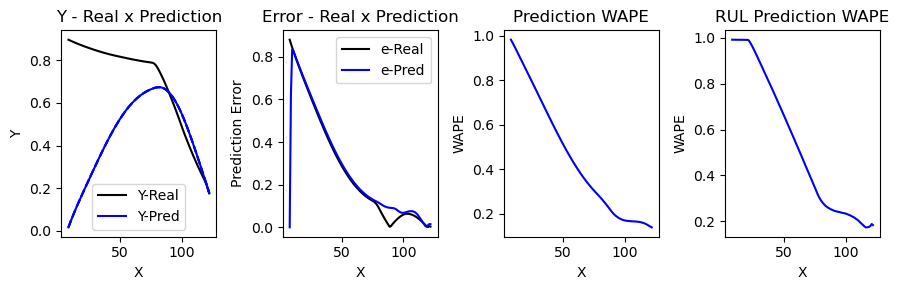

In [369]:
nI,nR,nO,N1,N2,N3,lr,τ= params
#nO=nI
ηS = [N1,N2,N3]
X,Y = prepare_data(sig,n=nI,m=nO)
rtlo = RTLO(nI,nR,nO,ηS,τ,lr)
rtlo.ref = len(sig)-nI
for i in range(len(X[:])):
    #rtlo.PredRul(x=X[i],store=True)
    rtlo.PredRulIntr(x=X[i],store=True)
    rtlo.fit(X[i],Y[i],start=0,store=True)
    
print(rtlo.yWAPE[-1])  
print(rtlo.rWAPE[-1])  
PlotPredError(rtlo)


In [419]:
ySeries =[rtlo.rulR,rtlo.rulP,rtlo.rulL,rtlo.rulU]
PlotSeries(ySeries=ySeries,mode='ply')

In [371]:
#nI,nR,N1,N2,N3,lr,τ= params
nI,nR,nO,N1,N2,N3,lr,τ= params
ηS = [N1,N2,N3]
X,Y = prepare_data(sig,n=nI,m=nO)
rnn = RTLO(nI,nR,nO,ηS,τ,lr)
rnn.ref = len(sig)-nI

i=0

In [418]:
rnn.PredRulIntr(x=X[i],store=True)
rnn.fit(X[i],Y[i],start=30,store=True, showY=True)
i=i+1

yP: [0.63955535 0.83929327 0.37004951 0.69798997 0.37619811 0.38764412
 0.56048235]
